In [2]:
from datetime import datetime
from getpass import getpass

rdm_url = 'https://bh.rdm.yzwlab.com/'
idp_name_1 = None
idp_username_1 = None
idp_password_1 = None
rdm_project_name = 'TEST-{}'.format(datetime.now().strftime('%Y%m%d-%H%M%S'))
target_storage_name = 'NII Storage'
target_storage_id = 'osfstorage'
delete_project = True
default_result_path = None
close_on_fail = False
transition_timeout = 10000

paper_doi = '10.52825/cordi.v1i.260'
paper_title_ja = 'オントロジー技術を用いたNII RDCアプリケーションプロファイルの開発'
paper_title_en = 'Toward the Development of NII RDC Application Profile Using Ontology Technology'
paper_publication_month = '2023-09'
paper_journal_name_ja = '研究データ基盤会議論文集'
paper_journal_name_en = 'Proceedings of the Conference on Research Data Infrastructure'
paper_journal_volume = '1'
paper_journal_issue = '1'
paper_page_start = '1'
paper_page_end = '8'
paper_note_ja = '書誌情報の入力を行いました。'
paper_note_en = 'Bibliographic metadata entry completed.'

paper_authors = [
    {
        'number': '70921876',
        'name_ja': {'last': '南山', 'middle': '', 'first': '泰行'},
        'name_en': {'last': 'Minamiyama', 'middle': '', 'first': 'Yasuyuki'},
        'affiliation_ja': '国立情報学研究所',
        'affiliation_en': 'National Institute of Informatics',
    },
]
paper_title_ja_rev = paper_title_ja + '（再編集）'
paper_title_en_rev = paper_title_en + ' (Revised)'
paper_note_ja_rev = '書誌情報の再編集を行いました。'
paper_note_en_rev = 'Bibliographic metadata re-edited.'


In [3]:
if idp_username_1 is None:
    idp_username_1 = input(prompt=f'Username for {idp_name_1}')
if idp_password_1 is None:
    idp_password_1 = getpass(prompt=f'Password for {idp_username_1}@{idp_name_1}')
(len(idp_username_1), len(idp_password_1))

(29, 13)

In [4]:
import tempfile

work_dir = tempfile.mkdtemp()
if default_result_path is None:
    default_result_path = work_dir
work_dir

'/var/folders/m0/myy2ys0s3cl_73__2gw8fw140000gn/T/tmp7e7f2mgn'

# 複数メタデータの一括設定（書誌情報入力）

- サブシステム名: アドオン
- ページ/アドオン: Metadata
- 機能分類: メタデータ入力
- シナリオ名: 論文の書誌情報を含む複数メタデータの一括設定
- 用意するテストデータ: DOI (10.52825/cordi.v1i.260)、URL一覧、アカウント(既存ユーザー1: GRDM)
- 事前条件: 「プロジェクトに対するMetadataアドオンの登録」を実施済みであること

複数選択したファイル/フォルダに対し、ファイル種別「論文」の専用項目をまとめて入力してもデータが壊れないことを確認する。


## ウェブブラウザの新規プライベートウィンドウでGRDMトップページを表示する

GRDMトップページが表示されること

In [5]:
import importlib
import pandas as pd

import scripts.playwright
importlib.reload(scripts.playwright)
from scripts.metadata_v2025 import FileMetadataForm

from scripts.playwright import *
from scripts import grdm

await init_pw_context(close_on_fail=close_on_fail, last_path=default_result_path)

('20250906-060630',
 '/var/folders/m0/myy2ys0s3cl_73__2gw8fw140000gn/T/tmpckkpcidw')

Start epoch: 1757106392.096858 seconds


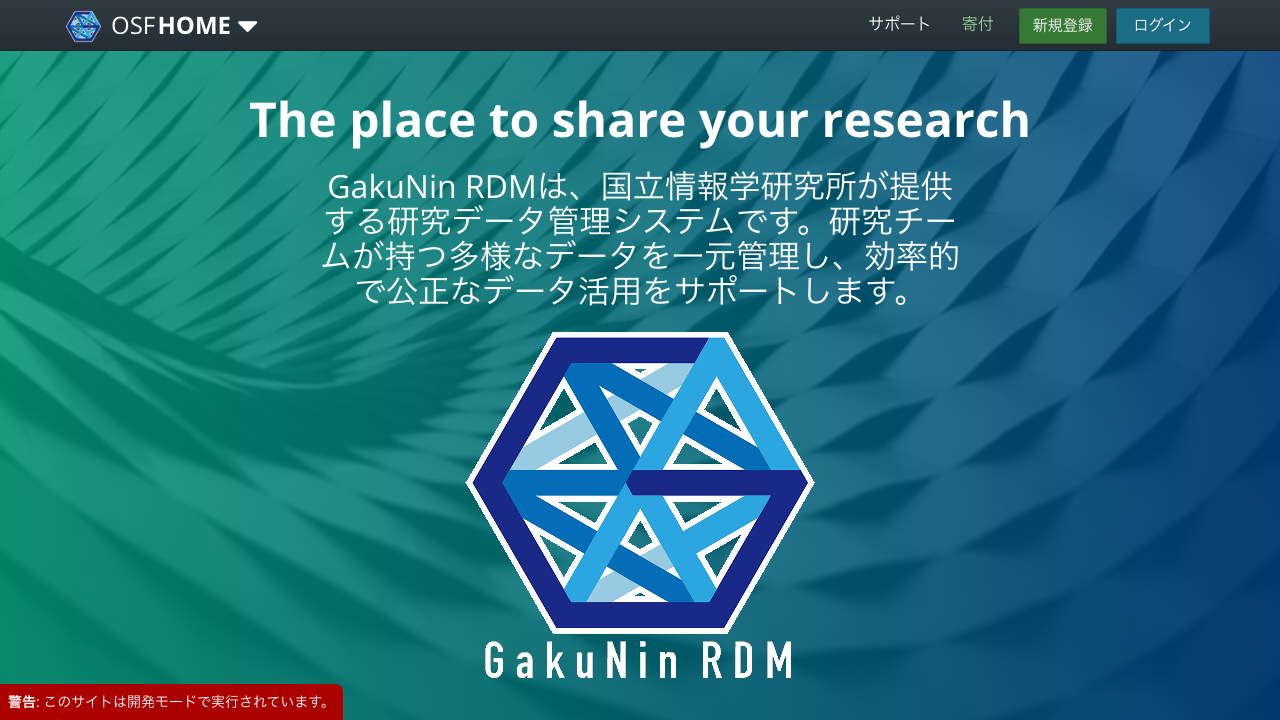

In [6]:
import time

async def _step(page):
    await page.goto(rdm_url)

    # 同意する をクリック
    await page.locator('//button[text() = "同意する"]').click()

    # 同意する が表示されなくなったことを確認
    await expect(page.locator('//button[text() = "同意する"]')).to_have_count(0, timeout=500)

await run_pw(_step)

## ログイン情報を用いてGakuNin RDMにログインする

(IdPに関するログイン情報が与えられた場合、)
GakuNin Embeded DSのプルダウンを展開し、IdPリストから指定されたIdPを選択する。その後、アカウントのID/Passwordを入力して「Login」ボタンを押下する。

(IdPが指定されていない場合、)
CASのログイン操作を実施する。

Start epoch: 1757106395.194953 seconds


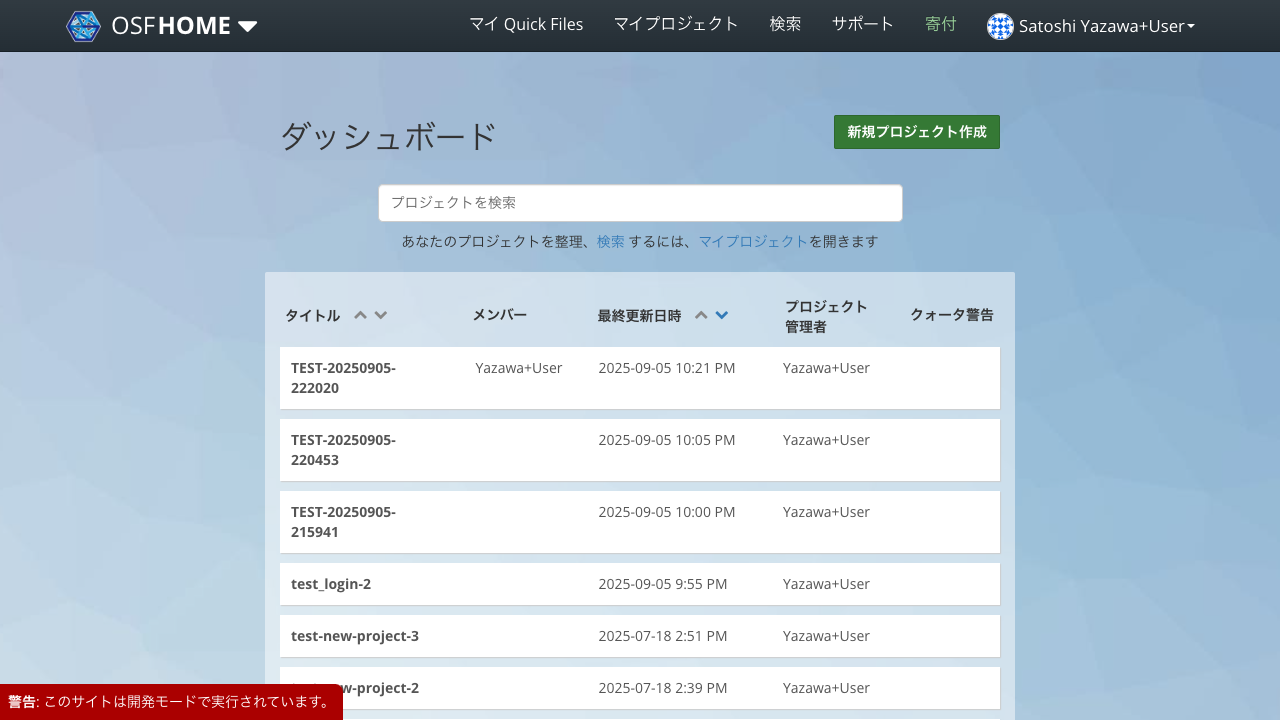

In [7]:
import scripts.grdm
importlib.reload(scripts.grdm)

async def _step(page):
    await scripts.grdm.login(
        page, idp_name_1, idp_username_1, idp_password_1, transition_timeout=transition_timeout
    )

    # GRDMのボタンが表示されることを確認
    await expect(page.locator('//*[text() = "プロジェクト管理者"]')).to_be_visible(timeout=transition_timeout)

await run_pw(_step)

## プロジェクト一覧に指定されたタイトルのプロジェクトがない場合、指定された名前のプロジェクトを作成する

プロジェクト一覧に当該プロジェクト名が表示されていない場合、「新規プロジェクト作成」をクリックし、その名前を入力、「作成」をクリックする。

Start epoch: 1757106402.851412 seconds


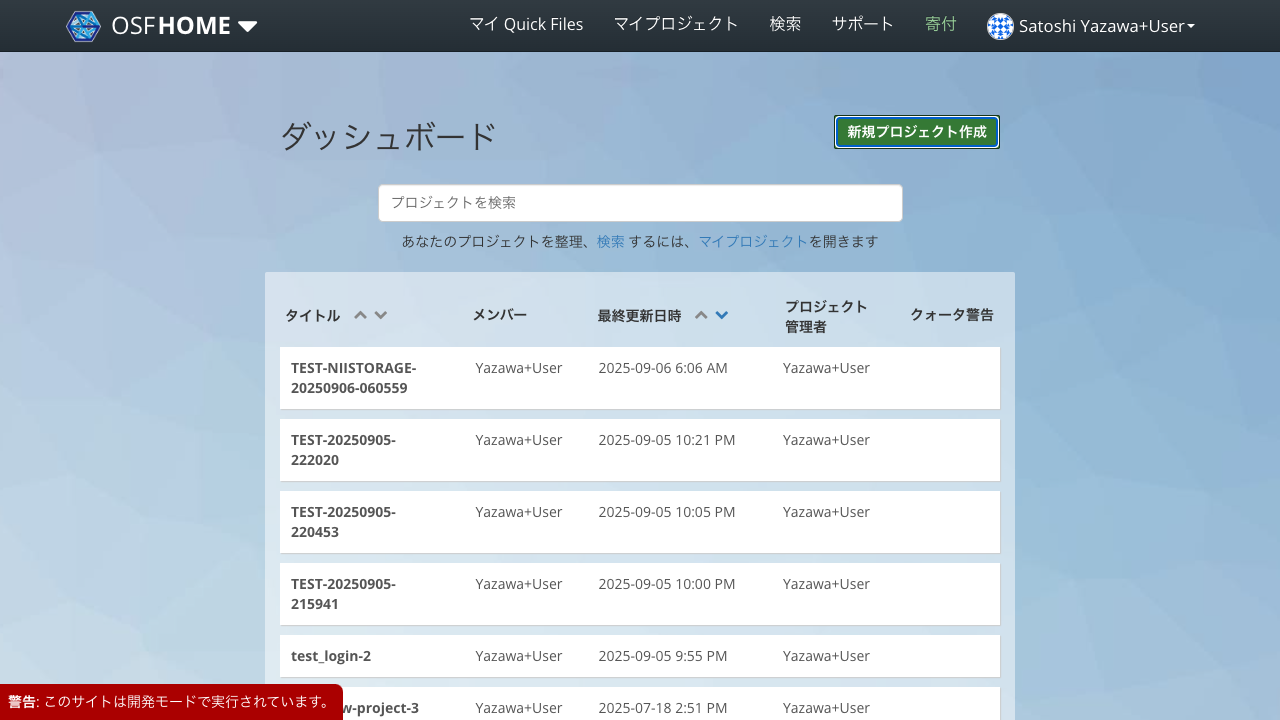

In [8]:
# import scripts.grdm
# importlib.reload(scripts.grdm)

async def _step(page):
    await expect(page.locator('//*[@data-test-create-project-modal-button]')).to_have_count(1)

    await scripts.grdm.ensure_project_exists(page, rdm_project_name, transition_timeout=transition_timeout)
        
await run_pw(_step)

## ダッシュボードのプロジェクト一覧から指定されたプロジェクトをクリックする

Start epoch: 1757106417.963076 seconds


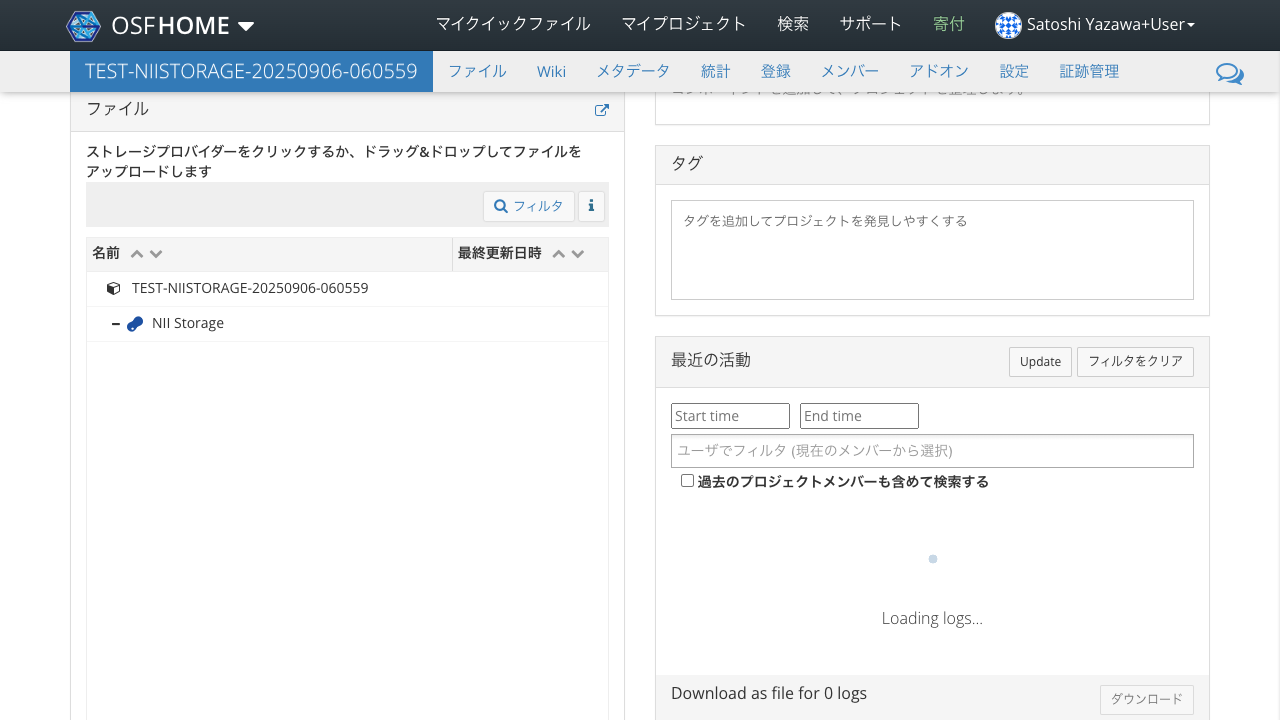

In [9]:
async def _step(page):
    await page.locator(f'//*[@data-test-dashboard-item-title and text()="{rdm_project_name}"]').click()        

    await expect(page.locator('//a[text() = "アドオン"]')).to_be_visible(timeout=transition_timeout)
    await expect(grdm.get_select_expanded_storage_title_locator(page, 'NII Storage')).to_be_visible(timeout=transition_timeout)
    time.sleep(1)

    await page.locator('//h3[text()="最近の活動"]').click()

await run_pw(_step)

## プロジェクトダッシュボードの上部メニューから「アドオン」をクリックする

「アドオンを構成」のパネル内に「Metadata」の行が表示されること

Start epoch: 1757106707.5323 seconds


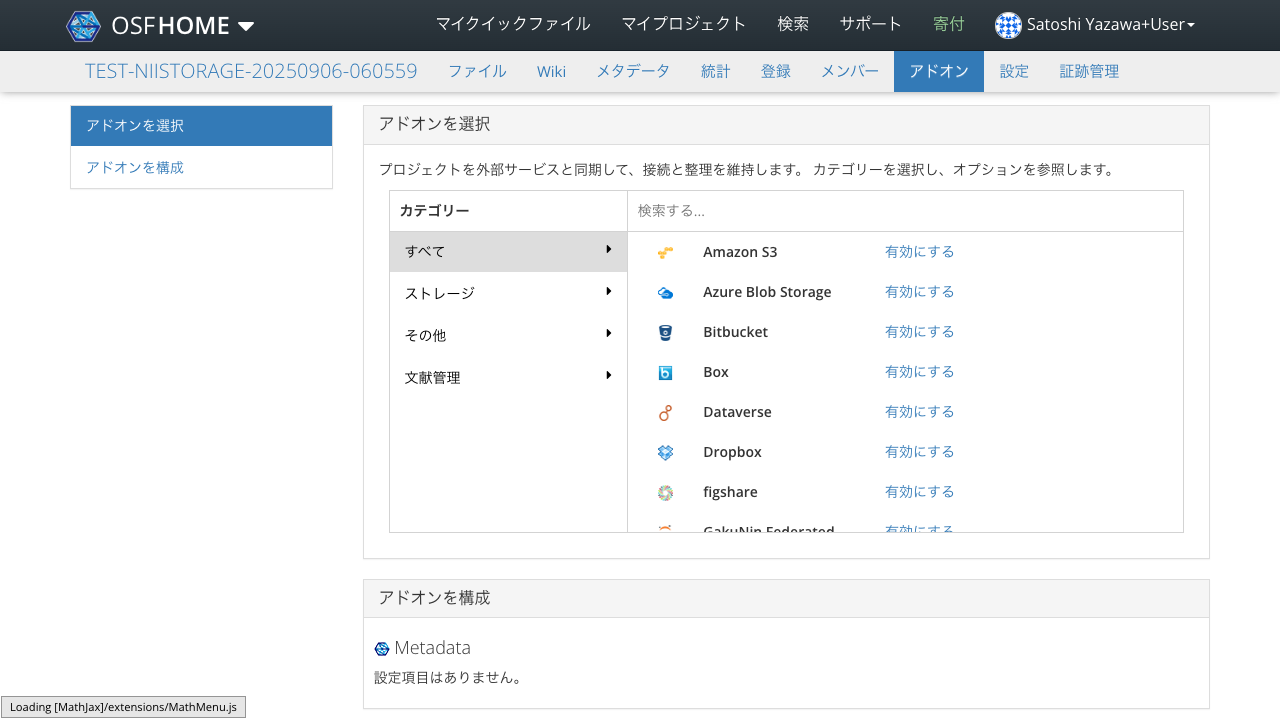

In [13]:
addon_name = 'Metadata'

async def _step(page):
    await page.locator('//a[text() = "アドオン"]').click()

    await expect(page.locator(f'//h4[@class="addon-title"][normalize-space(.)="Metadata"]')).to_be_visible(timeout=10000)

await run_pw(_step)

## プロジェクト名をクリックする

Start epoch: 1757106729.328077 seconds


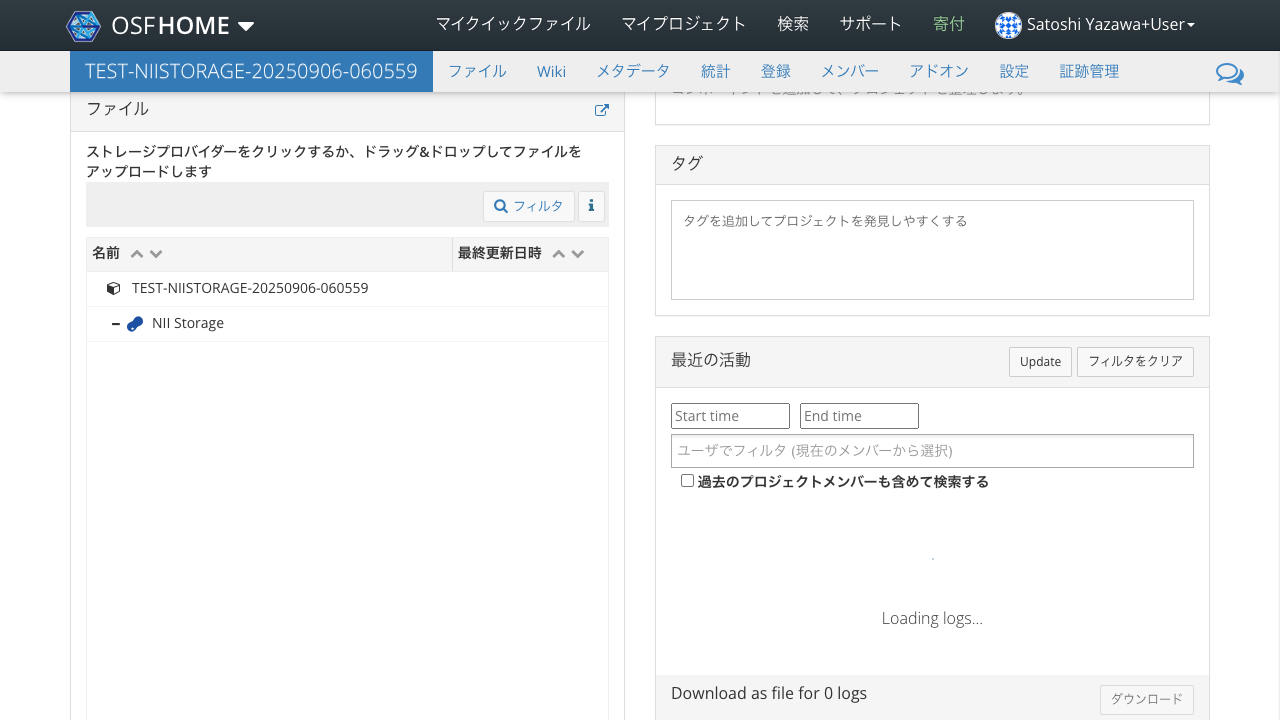

In [14]:
async def _step(page):
    await page.locator(f'//*[contains(@class, "project-title") and contains(text(), "{rdm_project_name}")]').click()        

    await expect(page.locator('//a[text() = "アドオン"]')).to_be_visible(timeout=transition_timeout)
    await expect(grdm.get_select_expanded_storage_title_locator(page, 'NII Storage')).to_be_visible(timeout=transition_timeout)
    time.sleep(1)

    await page.locator('//h3[text()="最近の活動"]').click()

await run_pw(_step)

## 「NII Storage」をクリックする

「メタデータ編集」ボタンが表示されること (表示まで数秒かかる可能性がある)

Start epoch: 1743769717.4458113 seconds


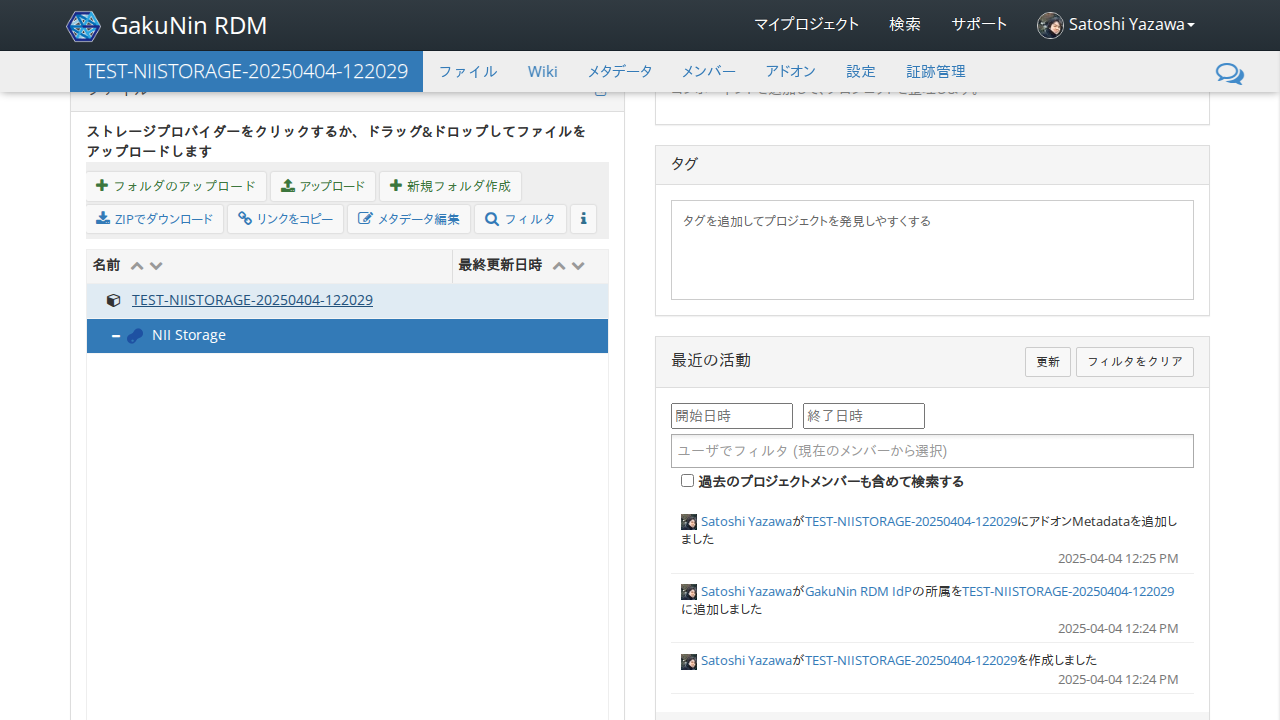

In [24]:
# import scripts.grdm
# importlib.reload(scripts.grdm)

async def _step(page):
    await grdm.get_select_storage_title_locator(page, 'NII Storage').click()
    
    await expect(page.locator('//*[text() = "メタデータ編集"]')).to_be_enabled(timeout=10000)

await run_pw(_step)

## 「新規フォルダ作成」をクリックする

フォルダ名入力テキストフィールドが表示されること

Start epoch: 1743769727.1990829 seconds


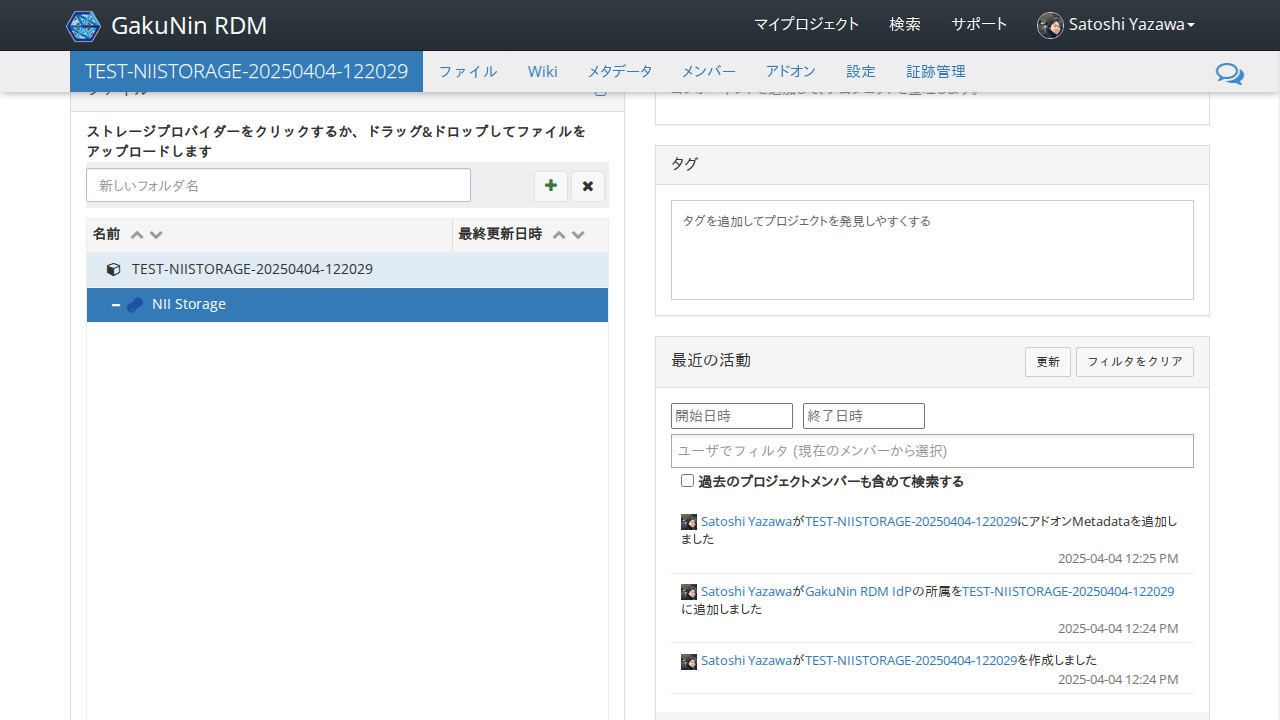

In [25]:
async def _step(page):
    await page.locator('//*[text() = "新規フォルダ作成"]').click()
    
    await expect(page.locator('//input[@id = "createFolderInput"]')).to_be_editable(timeout=transition_timeout)

await run_pw(_step)

## 「TESTMULTIPLE(ENTER)」を入力する

TESTMULTIPLEフォルダが作成されること

Start epoch: 1743769727.426373 seconds


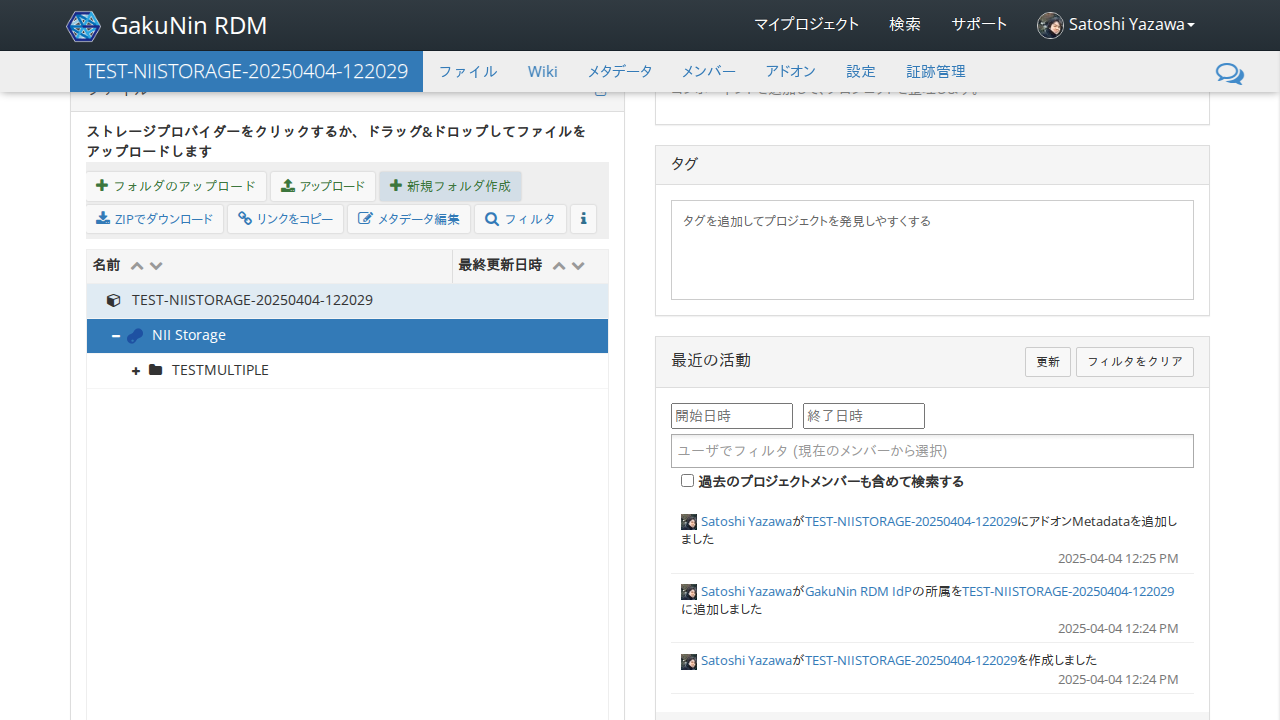

In [26]:
# import scripts.grdm
# importlib.reload(scripts.grdm)

async def _step(page):
    await page.locator('//input[@id = "createFolderInput"]').fill('TESTMULTIPLE')
    await page.keyboard.press('Enter')

    await expect(grdm.get_select_folder_title_locator(page, 'TESTMULTIPLE')).to_be_visible(timeout=30000)

await run_pw(_step)

## 「NII Storage」をクリックする

「メタデータ編集」ボタンが表示されること (表示まで数秒かかる可能性がある)

Start epoch: 1743769729.5353608 seconds


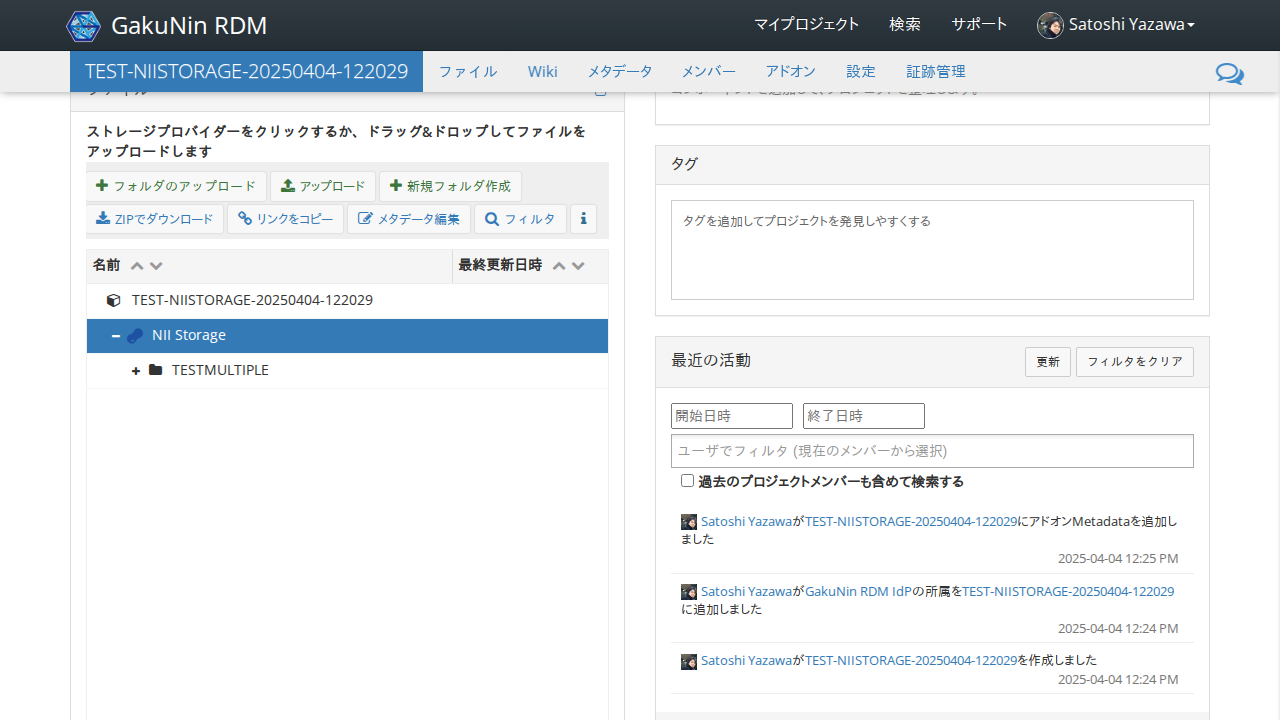

In [27]:
async def _step(page):
    await grdm.get_select_storage_title_locator(page, 'NII Storage').click()
    
    await expect(page.locator('//*[text() = "メタデータ編集"]')).to_be_enabled(timeout=10000)

await run_pw(_step)

## ファイルをアップロードする

テスト環境の「サンプル.png」をNII Storage配下にドラッグ＆ドロップする。

In [28]:
await save_screenshot(os.path.join(work_dir, 'サンプル.png'))

'/tmp/tmpbaeuofwa/サンプル.png'

Start epoch: 1743769794.4429238 seconds


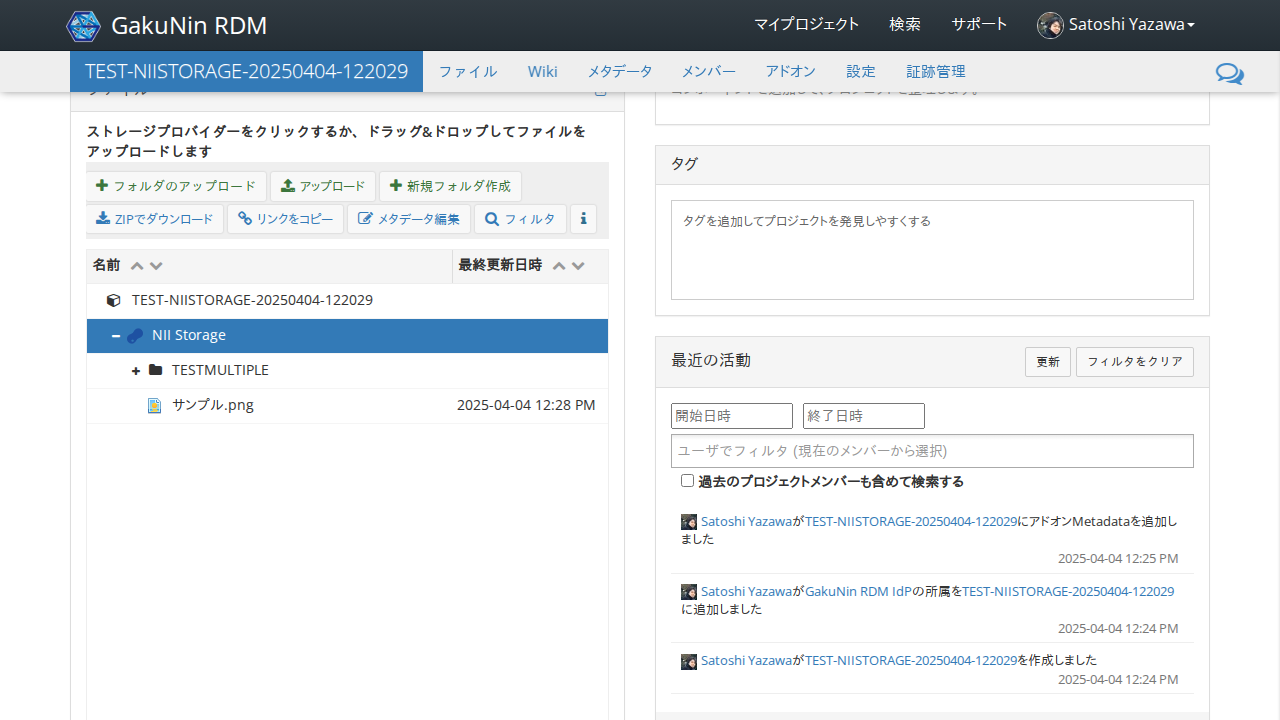

In [31]:
# progress-bar progress-bar-info progress-bar-striped active
# import scripts.grdm
# importlib.reload(scripts.grdm)

async def _step(page):
    dropzone = grdm.get_select_storage_title_xpath('NII Storage')
    await grdm.drop_file(page, dropzone, os.path.join(work_dir, 'サンプル.png'))
    time.sleep(1)

    await expect(page.locator('//*[text() = "サンプル.png"]/../following-sibling::*//*[@role = "progressbar"]')).to_have_count(0, timeout=30000)
    await expect(grdm.get_select_file_title_locator(page, 'サンプル.png')).to_be_visible(timeout=transition_timeout)

await run_pw(_step)

## 「サンプル.png」のアイコンをクリックする

「メタデータ編集」ボタンが表示されること (表示まで数秒かかる可能性がある)

Start epoch: 1743769811.969032 seconds


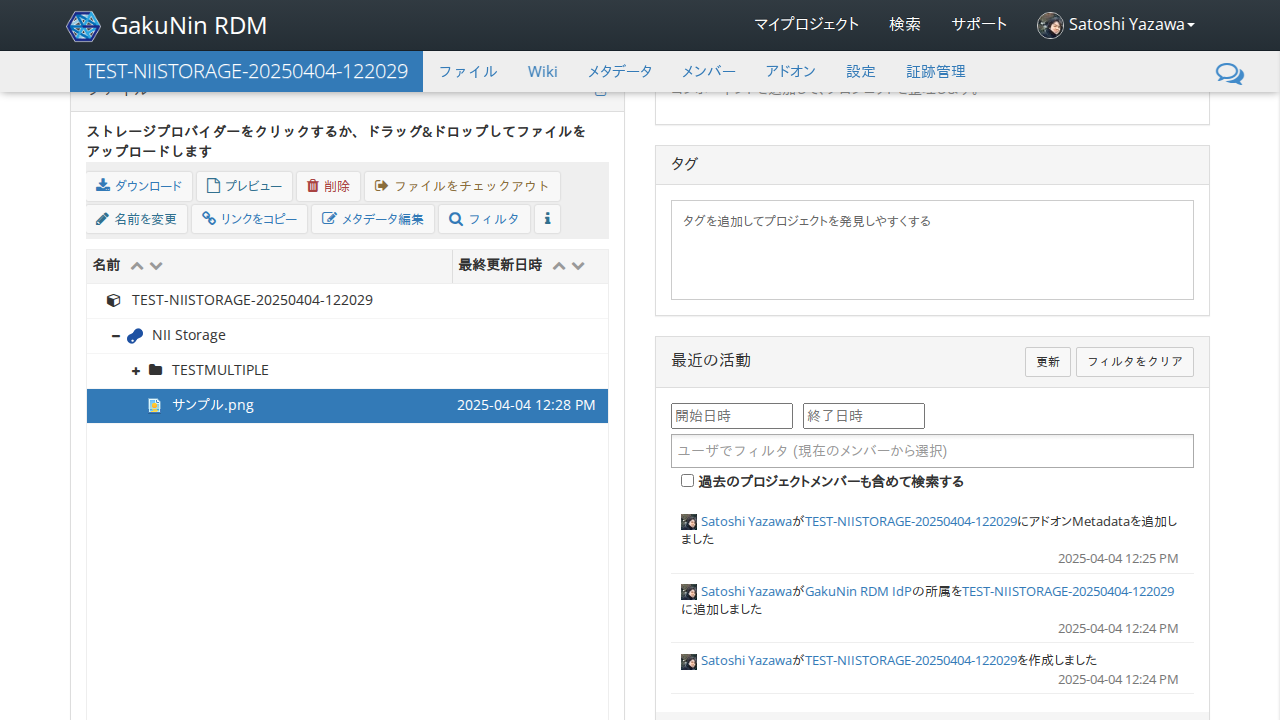

In [32]:
# import scripts.grdm
# importlib.reload(scripts.grdm)

async def _step(page):
    await grdm.get_select_file_extension_locator(page, 'サンプル.png').click()
    await expect(page.locator('//*[text() = "メタデータ編集"]')).to_be_enabled(timeout=10000)

await run_pw(_step)

## Shiftキーを押しながら「TESTMULTIPLE」をクリックする

「サンプル.png」と「TESTMULTIPLE」の両方が選択状態になり、「メタデータ複数編集」ボタンが表示されること (表示まで数秒かかる可能性がある)

Start epoch: 1743769812.1971855 seconds


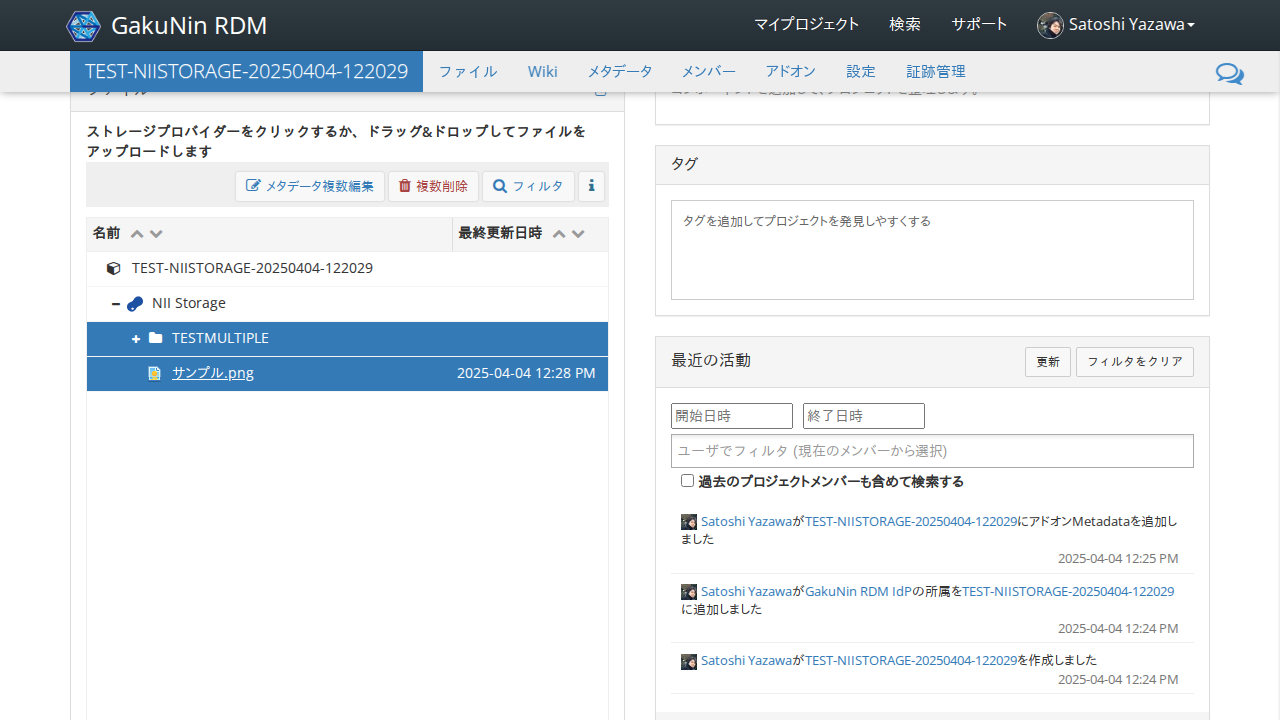

In [33]:
async def _step(page):
    await grdm.get_select_folder_title_locator(page, 'TESTMULTIPLE').click(modifiers=['Shift'])
    await expect(page.locator('//*[text() = "メタデータ複数編集"]')).to_be_enabled(timeout=10000)
    await expect(page.locator('//*[text() = "メタデータ編集"]')).to_have_count(0, timeout=transition_timeout)

await run_pw(_step)

##  「メタデータ複数編集」をクリックする

「ファイルメタデータの複数編集」ダイアログが表示されること

Start epoch: 1743769812.4295511 seconds


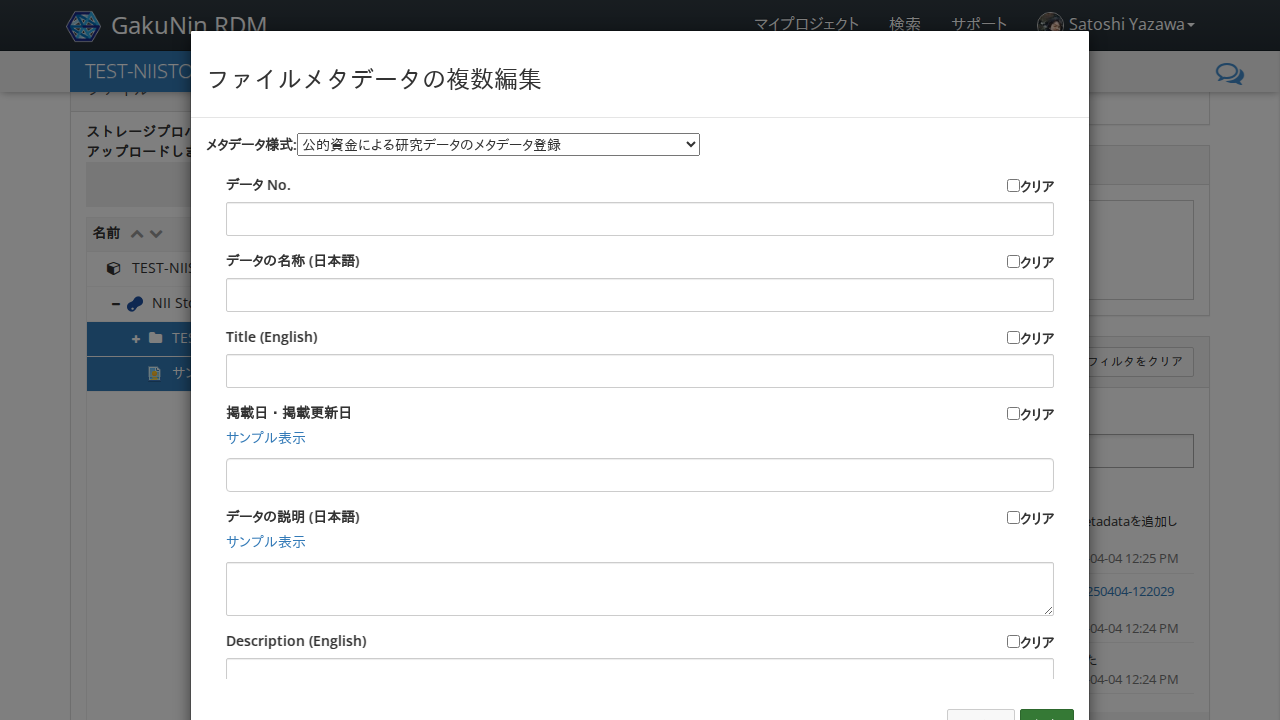

In [34]:
async def _step(page):
    await page.locator('//*[text() = "メタデータ複数編集"]').click()

    await expect(page.locator('//label[contains(text(), "メタデータ様式")]/following-sibling::select').first).to_be_editable(timeout=transition_timeout)
    time.sleep(1)

await run_pw(_step)

##  「メタデータ様式」に「公的資金による研究データのメタデータ登録」を入力する

「データNo.」フィールドが表示されること

Start epoch: 1743769813.7102065 seconds


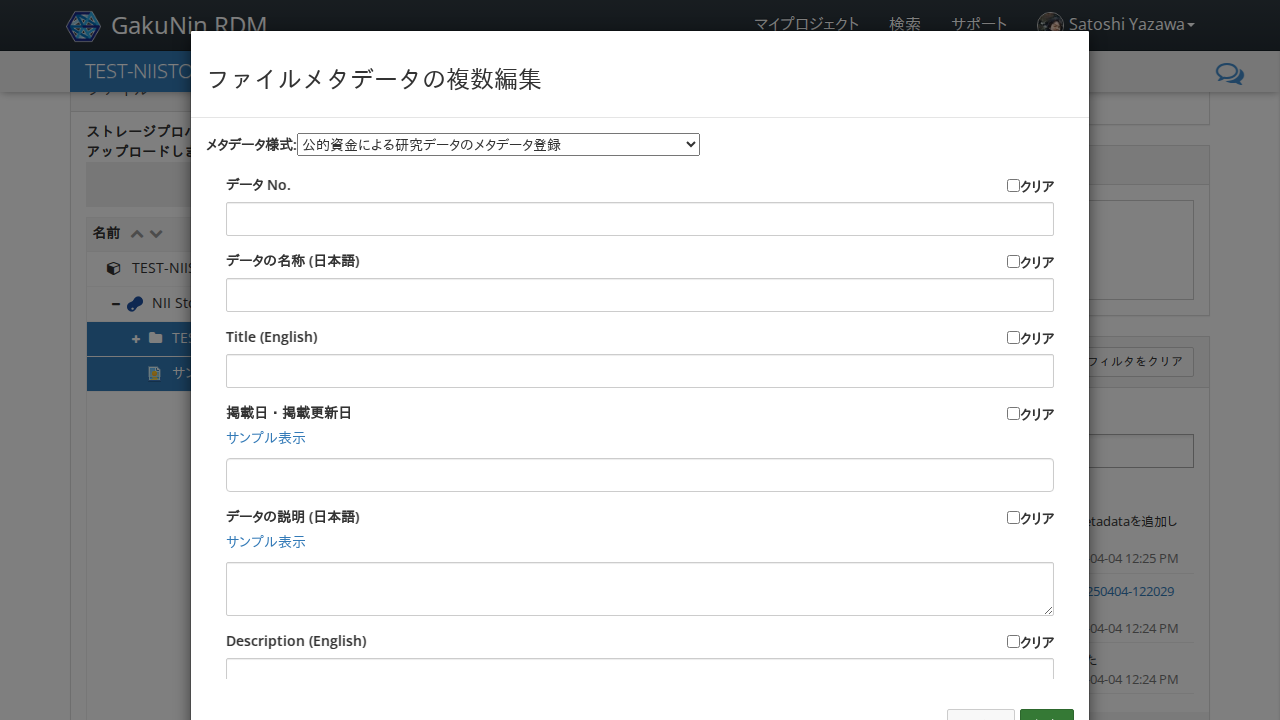

In [35]:
async def _step(page):
    await page.locator('//label[contains(text(), "メタデータ様式")]/following-sibling::select').select_option('公的資金による研究データのメタデータ登録')

    await expect(page.locator('//label[contains(text(), "データ No.")]/../following-sibling::div[1]//input')).to_be_editable(timeout=transition_timeout)

await run_pw(_step)

## 「ファイル種別」で「論文」を選択する

論文専用項目が表示されること

In [ ]:
async def _step(page):
    form = FileMetadataForm(page, parent_locator=page.locator('//h3[text() = "ファイルメタデータの複数編集"]/../../..'))
    locator = form.get_locator('ファイル種別')
    await locator.select_option('manuscript')
    await expect(locator).to_have_value('manuscript', timeout=transition_timeout)

await run_pw(_step)


## 「データの名称(日本語)」に論文タイトルを入力する

In [ ]:
async def _step(page):
    form = FileMetadataForm(page, parent_locator=page.locator('//h3[text() = "ファイルメタデータの複数編集"]/../../..'))
    await form.fill('データの名称または論文表題 (日本語)', paper_title_ja)
    await expect(form.get_locator('データの名称または論文表題 (日本語)')).to_have_value(paper_title_ja, timeout=transition_timeout)

await run_pw(_step)


## 「Title (English)」に論文タイトルを入力する

In [ ]:
async def _step(page):
    form = FileMetadataForm(page, parent_locator=page.locator('//h3[text() = "ファイルメタデータの複数編集"]/../../..'))
    await form.fill('Title (English)', paper_title_en)
    await expect(form.get_locator('Title (English)')).to_have_value(paper_title_en, timeout=transition_timeout)

await run_pw(_step)


## 「論文（出版社版）のDOI」に DOI を入力する

In [ ]:
async def _step(page):
    form = FileMetadataForm(page, parent_locator=page.locator('//h3[text() = "ファイルメタデータの複数編集"]/../../..'))
    await form.fill('論文（出版社版）のDOI', paper_doi)
    await expect(form.get_locator('論文（出版社版）のDOI')).to_have_value(paper_doi, timeout=transition_timeout)

await run_pw(_step)


## 「論文の種類」で「学術雑誌論文」を選択する

In [ ]:
async def _step(page):
    form = FileMetadataForm(page, parent_locator=page.locator('//h3[text() = "ファイルメタデータの複数編集"]/../../..'))
    locator = form.get_locator('論文の種類')
    await locator.select_option('journal article')
    await expect(locator).to_have_value('journal article', timeout=transition_timeout)

await run_pw(_step)


## 「著者名」を入力する

In [ ]:
async def _step(page):
    form = FileMetadataForm(page, parent_locator=page.locator('//h3[text() = "ファイルメタデータの複数編集"]/../../..'))
    for author in paper_authors:
        await form.fill_author(author)

await run_pw(_step)


## 「掲載誌名 (日本語)」に掲載誌名を入力する

In [ ]:
async def _step(page):
    form = FileMetadataForm(page, parent_locator=page.locator('//h3[text() = "ファイルメタデータの複数編集"]/../../..'))
    await form.fill('掲載誌名 (日本語)', paper_journal_name_ja)
    await expect(form.get_locator('掲載誌名 (日本語)')).to_have_value(paper_journal_name_ja, timeout=transition_timeout)

await run_pw(_step)


## 「Journal Name (English)」に掲載誌名を入力する

In [ ]:
async def _step(page):
    form = FileMetadataForm(page, parent_locator=page.locator('//h3[text() = "ファイルメタデータの複数編集"]/../../..'))
    await form.fill('Journal Name (English)', paper_journal_name_en)
    await expect(form.get_locator('Journal Name (English)')).to_have_value(paper_journal_name_en, timeout=transition_timeout)

await run_pw(_step)


## 「発行年月」に公開年月を入力する

In [ ]:
async def _step(page):
    form = FileMetadataForm(page, parent_locator=page.locator('//h3[text() = "ファイルメタデータの複数編集"]/../../..'))
    await form.fill('発行年月', paper_publication_month)
    await expect(form.get_locator('発行年月')).to_have_value(paper_publication_month, timeout=transition_timeout)

await run_pw(_step)


## 「巻」に「1」を入力する

In [ ]:
async def _step(page):
    form = FileMetadataForm(page, parent_locator=page.locator('//h3[text() = "ファイルメタデータの複数編集"]/../../..'))
    await form.fill('巻', paper_journal_volume)
    await expect(form.get_locator('巻')).to_have_value(paper_journal_volume, timeout=transition_timeout)

await run_pw(_step)


## 「号」に「1」を入力する

In [ ]:
async def _step(page):
    form = FileMetadataForm(page, parent_locator=page.locator('//h3[text() = "ファイルメタデータの複数編集"]/../../..'))
    await form.fill('号', paper_journal_issue)
    await expect(form.get_locator('号')).to_have_value(paper_journal_issue, timeout=transition_timeout)

await run_pw(_step)


## 「掲載ページ (開始)」にページ番号を入力する

In [ ]:
async def _step(page):
    form = FileMetadataForm(page, parent_locator=page.locator('//h3[text() = "ファイルメタデータの複数編集"]/../../..'))
    await form.fill('掲載ページ (開始)', paper_page_start)
    await expect(form.get_locator('掲載ページ (開始)')).to_have_value(paper_page_start, timeout=transition_timeout)

await run_pw(_step)


## 「掲載ページ (終了)」にページ番号を入力する

In [ ]:
async def _step(page):
    form = FileMetadataForm(page, parent_locator=page.locator('//h3[text() = "ファイルメタデータの複数編集"]/../../..'))
    await form.fill('掲載ページ (終了)', paper_page_end)
    await expect(form.get_locator('掲載ページ (終了)')).to_have_value(paper_page_end, timeout=transition_timeout)

await run_pw(_step)


## 「査読の有無」で「あり」を選択する

In [ ]:
async def _step(page):
    form = FileMetadataForm(page, parent_locator=page.locator('//h3[text() = "ファイルメタデータの複数編集"]/../../..'))
    locator = form.get_locator('査読の有無')
    await locator.select_option('yes')
    await expect(locator).to_have_value('yes', timeout=transition_timeout)

await run_pw(_step)


## 「版情報」で「著者最終稿」を選択する

In [ ]:
async def _step(page):
    form = FileMetadataForm(page, parent_locator=page.locator('//h3[text() = "ファイルメタデータの複数編集"]/../../..'))
    locator = form.get_locator('版情報')
    await locator.select_option('AM')
    await expect(locator).to_have_value('AM', timeout=transition_timeout)

await run_pw(_step)


## 「備考 (日本語)」に補足を入力する

In [ ]:
async def _step(page):
    form = FileMetadataForm(page, parent_locator=page.locator('//h3[text() = "ファイルメタデータの複数編集"]/../../..'))
    await form.fill('備考 (日本語)', paper_note_ja)
    await expect(form.get_locator('備考 (日本語)')).to_have_value(paper_note_ja, timeout=transition_timeout)

await run_pw(_step)


## 「Remarks (English)」に補足を入力する

In [ ]:
async def _step(page):
    form = FileMetadataForm(page, parent_locator=page.locator('//h3[text() = "ファイルメタデータの複数編集"]/../../..'))
    await form.fill('Remarks (English)', paper_note_en)
    await expect(form.get_locator('Remarks (English)')).to_have_value(paper_note_en, timeout=transition_timeout)

await run_pw(_step)


## 「保存」をクリックする

ダイアログが非表示になること

In [ ]:
async def _step(page):
    await page.locator('//h3[text() = "ファイルメタデータの複数編集"]/../../..//a[text() = "保存"]').click()
    await expect(page.locator('//h3[text() = "ファイルメタデータの複数編集"]/../../..//label[contains(text(), "Remarks (English)")]/../following-sibling::textarea[1]')).not_to_be_visible(timeout=10000)

await run_pw(_step)


## 「TESTMULTIPLE」をクリックする

「メタデータ編集」ボタンが表示されること (表示まで数秒かかる可能性がある)

In [ ]:
async def _step(page):
    await grdm.get_select_folder_title_locator(page, 'TESTMULTIPLE').click()
    await expect(page.locator('//*[text() = "メタデータ編集"]')).to_be_enabled(timeout=10000)

await run_pw(_step)


## 「メタデータ編集」をクリックし、論文向け項目が反映されていることを確認する

- ファイル種別が「論文」になっていること
- 著者名を含む論文タイトル（日本語/英語）、DOI、論文の種類、掲載誌名、発行年月、巻・号、掲載ページが入力済みであること
- 査読の有無と版情報、備考(日/英)が入力済みであること


In [ ]:
async def _step(page):
    await page.locator('//*[text() = "メタデータ編集"]').click()
    form = FileMetadataForm(page, parent_locator=page.locator('//h3[text() = "ファイルメタデータの編集"]/../../..'))

    await expect(form.get_locator('ファイル種別')).to_have_value('manuscript', timeout=transition_timeout)
    await expect(form.get_locator('データの名称または論文表題 (日本語)')).to_have_value(paper_title_ja, timeout=transition_timeout)
    await expect(form.get_locator('Title (English)')).to_have_value(paper_title_en, timeout=transition_timeout)
    await expect(form.get_locator('論文（出版社版）のDOI')).to_have_value(paper_doi, timeout=transition_timeout)
    await expect(form.get_locator('論文の種類')).to_have_value('journal article', timeout=transition_timeout)
    await expect(form.get_locator('掲載誌名 (日本語)')).to_have_value(paper_journal_name_ja, timeout=transition_timeout)
    await expect(form.get_locator('Journal Name (English)')).to_have_value(paper_journal_name_en, timeout=transition_timeout)
    await expect(form.get_locator('発行年月')).to_have_value(paper_publication_month, timeout=transition_timeout)
    await expect(form.get_locator('巻')).to_have_value(paper_journal_volume, timeout=transition_timeout)
    await expect(form.get_locator('号')).to_have_value(paper_journal_issue, timeout=transition_timeout)
    await expect(form.get_locator('掲載ページ (開始)')).to_have_value(paper_page_start, timeout=transition_timeout)
    await expect(form.get_locator('掲載ページ (終了)')).to_have_value(paper_page_end, timeout=transition_timeout)
    await expect(form.get_locator('査読の有無')).to_have_value('yes', timeout=transition_timeout)
    await expect(form.get_locator('版情報')).to_have_value('AM', timeout=transition_timeout)
    await expect(form.get_locator('備考 (日本語)')).to_have_value(paper_note_ja, timeout=transition_timeout)
    await expect(form.get_locator('Remarks (English)')).to_have_value(paper_note_en, timeout=transition_timeout)

    authors_locator = form.get_locator('著者名').locator('tbody tr')
    if await authors_locator.count() < len(paper_authors):
        raise AssertionError('著者名の行数が不足しています')

await run_pw(_step)


## 「閉じる」をクリックする

ダイアログが非表示になること

In [ ]:
async def _step(page):
    await page.locator('//h3[text() = "ファイルメタデータの編集"]/../../..//a[text() = "閉じる"]').click()
    await expect(page.locator('//h3[text() = "ファイルメタデータの編集"]/../../..//label[contains(text(), "Remarks (English)")]/../following-sibling::textarea[1]')).not_to_be_visible(timeout=10000)

await run_pw(_step)


## 「サンプル.png」のアイコンをクリックする

「メタデータ編集」ボタンが表示されること (表示まで数秒かかる可能性がある)

In [ ]:
async def _step(page):
    await grdm.get_select_file_extension_locator(page, 'サンプル.png').click()
    await expect(page.locator('//*[text() = "メタデータ編集"]')).to_be_enabled(timeout=10000)

await run_pw(_step)


## 「メタデータ編集」をクリックし、論文向け項目が反映されていることを確認する

- ファイル種別が「論文」になっていること
- 著者名を含む論文タイトル（日本語/英語）、DOI、論文の種類、掲載誌名、発行年月、巻・号、掲載ページが入力済みであること
- 査読の有無と版情報、備考(日/英)が入力済みであること


In [ ]:
async def _step(page):
    await page.locator('//*[text() = "メタデータ編集"]').click()
    form = FileMetadataForm(page, parent_locator=page.locator('//h3[text() = "ファイルメタデータの編集"]/../../..'))

    await expect(form.get_locator('ファイル種別')).to_have_value('manuscript', timeout=transition_timeout)
    await expect(form.get_locator('データの名称または論文表題 (日本語)')).to_have_value(paper_title_ja, timeout=transition_timeout)
    await expect(form.get_locator('Title (English)')).to_have_value(paper_title_en, timeout=transition_timeout)
    await expect(form.get_locator('論文（出版社版）のDOI')).to_have_value(paper_doi, timeout=transition_timeout)
    await expect(form.get_locator('論文の種類')).to_have_value('journal article', timeout=transition_timeout)
    await expect(form.get_locator('掲載誌名 (日本語)')).to_have_value(paper_journal_name_ja, timeout=transition_timeout)
    await expect(form.get_locator('Journal Name (English)')).to_have_value(paper_journal_name_en, timeout=transition_timeout)
    await expect(form.get_locator('発行年月')).to_have_value(paper_publication_month, timeout=transition_timeout)
    await expect(form.get_locator('巻')).to_have_value(paper_journal_volume, timeout=transition_timeout)
    await expect(form.get_locator('号')).to_have_value(paper_journal_issue, timeout=transition_timeout)
    await expect(form.get_locator('掲載ページ (開始)')).to_have_value(paper_page_start, timeout=transition_timeout)
    await expect(form.get_locator('掲載ページ (終了)')).to_have_value(paper_page_end, timeout=transition_timeout)
    await expect(form.get_locator('査読の有無')).to_have_value('yes', timeout=transition_timeout)
    await expect(form.get_locator('版情報')).to_have_value('AM', timeout=transition_timeout)
    await expect(form.get_locator('備考 (日本語)')).to_have_value(paper_note_ja, timeout=transition_timeout)
    await expect(form.get_locator('Remarks (English)')).to_have_value(paper_note_en, timeout=transition_timeout)

    authors_locator = form.get_locator('著者名').locator('tbody tr')
    if await authors_locator.count() < len(paper_authors):
        raise AssertionError('著者名の行数が不足しています')

await run_pw(_step)


## 「閉じる」をクリックする

ダイアログが非表示になること

In [ ]:
async def _step(page):
    await page.locator('//h3[text() = "ファイルメタデータの編集"]/../../..//a[text() = "閉じる"]').click()
    await expect(page.locator('//h3[text() = "ファイルメタデータの編集"]/../../..//label[contains(text(), "Remarks (English)")]/../following-sibling::textarea[1]')).not_to_be_visible(timeout=10000)

await run_pw(_step)


## 「サンプル.png」のアイコンをクリックする（再編集）

「メタデータ編集」ボタンが表示されること (表示まで数秒かかる可能性がある)

In [ ]:
async def _step(page):
    await grdm.get_select_file_extension_locator(page, 'サンプル.png').click()
    await expect(page.locator('//*[text() = "メタデータ編集"]')).to_be_enabled(timeout=10000)

await run_pw(_step)


## Shiftキーを押しながら「TESTMULTIPLE」をクリックする（再編集）

「サンプル.png」と「TESTMULTIPLE」の両方が選択状態になり、「メタデータ複数編集」ボタンが表示されること (表示まで数秒かかる可能性がある)

In [ ]:
async def _step(page):
    await grdm.get_select_folder_title_locator(page, 'TESTMULTIPLE').click(modifiers=['Shift'])
    await expect(page.locator('//*[text() = "メタデータ複数編集"]')).to_be_enabled(timeout=10000)
    await expect(page.locator('//*[text() = "メタデータ編集"]')).to_have_count(0, timeout=transition_timeout)

await run_pw(_step)


## 「メタデータ複数編集」をクリックする（再編集）

「ファイルメタデータの複数編集」ダイアログが表示されること

In [ ]:
async def _step(page):
    await page.locator('//*[text() = "メタデータ複数編集"]').click()

    await expect(page.locator('//label[contains(text(), "メタデータ様式")]/following-sibling::select').first).to_be_editable(timeout=transition_timeout)
    time.sleep(1)

await run_pw(_step)


## 「データの名称(日本語)」を再編集する

入力した値が表示されること

In [ ]:
async def _step(page):
    form = FileMetadataForm(page, parent_locator=page.locator('//h3[text() = "ファイルメタデータの複数編集"]/../../..'))
    locator = form.get_locator('データの名称または論文表題 (日本語)')
    locator = locator.first
    await locator.fill(paper_title_ja_rev)
    await expect(locator).to_have_value(paper_title_ja_rev, timeout=transition_timeout)

await run_pw(_step)


## 「Title (English)」を再編集する

入力した値が表示されること

In [ ]:
async def _step(page):
    form = FileMetadataForm(page, parent_locator=page.locator('//h3[text() = "ファイルメタデータの複数編集"]/../../..'))
    locator = form.get_locator('Title (English)')
    locator = locator.first
    await locator.fill(paper_title_en_rev)
    await expect(locator).to_have_value(paper_title_en_rev, timeout=transition_timeout)

await run_pw(_step)


## 「備考 (日本語)」を再編集する

入力した値が表示されること

In [ ]:
async def _step(page):
    form = FileMetadataForm(page, parent_locator=page.locator('//h3[text() = "ファイルメタデータの複数編集"]/../../..'))
    locator = form.get_locator('備考 (日本語)')
    locator = locator.first
    await locator.fill(paper_note_ja_rev)
    await expect(locator).to_have_value(paper_note_ja_rev, timeout=transition_timeout)

await run_pw(_step)


## 「Remarks (English)」を再編集する

入力した値が表示されること

In [ ]:
async def _step(page):
    form = FileMetadataForm(page, parent_locator=page.locator('//h3[text() = "ファイルメタデータの複数編集"]/../../..'))
    locator = form.get_locator('Remarks (English)')
    locator = locator.first
    await locator.fill(paper_note_en_rev)
    await expect(locator).to_have_value(paper_note_en_rev, timeout=transition_timeout)

await run_pw(_step)


## 「保存」をクリックして再編集内容を反映する

ダイアログが非表示になること

In [ ]:
async def _step(page):
    await page.locator('//h3[text() = "ファイルメタデータの複数編集"]/../../..//a[text() = "保存"]').click()
    await expect(page.locator('//h3[text() = "ファイルメタデータの複数編集"]/../../..//label[contains(text(), "Remarks (English)")]/../following-sibling::textarea[1]')).not_to_be_visible(timeout=10000)

await run_pw(_step)


## 「TESTMULTIPLE」をクリックし再編集結果を確認する

「メタデータ編集」ボタンが表示されること (表示まで数秒かかる可能性がある)

In [ ]:
async def _step(page):
    await grdm.get_select_folder_title_locator(page, 'TESTMULTIPLE').click()
    await expect(page.locator('//*[text() = "メタデータ編集"]')).to_be_enabled(timeout=10000)

await run_pw(_step)


## 「メタデータ編集」をクリックし、再編集内容が反映されていることを確認する

- 論文タイトル（日本語/英語）が再編集後の値になっていること
- 備考 (日本語/English) が再編集後の値になっていること

In [ ]:
async def _step(page):
    await page.locator('//*[text() = "メタデータ編集"]').click()
    form = FileMetadataForm(page, parent_locator=page.locator('//h3[text() = "ファイルメタデータの編集"]/../../..'))

    await expect(form.get_locator('データの名称または論文表題 (日本語)')).to_have_value(paper_title_ja_rev, timeout=transition_timeout)
    await expect(form.get_locator('Title (English)')).to_have_value(paper_title_en_rev, timeout=transition_timeout)
    await expect(form.get_locator('備考 (日本語)')).to_have_value(paper_note_ja_rev, timeout=transition_timeout)
    await expect(form.get_locator('Remarks (English)')).to_have_value(paper_note_en_rev, timeout=transition_timeout)

await run_pw(_step)


## 「閉じる」をクリックする

ダイアログが非表示になること

In [ ]:
async def _step(page):
    await page.locator('//h3[text() = "ファイルメタデータの編集"]/../../..//a[text() = "閉じる"]').click()
    await expect(page.locator('//h3[text() = "ファイルメタデータの編集"]/../../..//label[contains(text(), "Remarks (English)")]/../following-sibling::textarea[1]')).not_to_be_visible(timeout=10000)

await run_pw(_step)


## 「サンプル.png」のアイコンをクリックし再編集結果を確認する

「メタデータ編集」ボタンが表示されること (表示まで数秒かかる可能性がある)

In [ ]:
async def _step(page):
    await grdm.get_select_file_extension_locator(page, 'サンプル.png').click()
    await expect(page.locator('//*[text() = "メタデータ編集"]')).to_be_enabled(timeout=10000)

await run_pw(_step)


## 「メタデータ編集」をクリックし、サンプルファイルにも再編集内容が反映されていることを確認する

In [ ]:
async def _step(page):
    await page.locator('//*[text() = "メタデータ編集"]').click()
    form = FileMetadataForm(page, parent_locator=page.locator('//h3[text() = "ファイルメタデータの編集"]/../../..'))

    await expect(form.get_locator('データの名称または論文表題 (日本語)')).to_have_value(paper_title_ja_rev, timeout=transition_timeout)
    await expect(form.get_locator('Title (English)')).to_have_value(paper_title_en_rev, timeout=transition_timeout)
    await expect(form.get_locator('備考 (日本語)')).to_have_value(paper_note_ja_rev, timeout=transition_timeout)
    await expect(form.get_locator('Remarks (English)')).to_have_value(paper_note_en_rev, timeout=transition_timeout)

await run_pw(_step)


## 「閉じる」をクリックする

ダイアログが非表示になること

In [ ]:
async def _step(page):
    await page.locator('//h3[text() = "ファイルメタデータの編集"]/../../..//a[text() = "閉じる"]').click()
    await expect(page.locator('//h3[text() = "ファイルメタデータの編集"]/../../..//label[contains(text(), "Remarks (English)")]/../following-sibling::textarea[1]')).not_to_be_visible(timeout=10000)

await run_pw(_step)


## 「サンプル.png」のアイコンをクリックしクリア操作の準備をする

「メタデータ編集」ボタンが表示されること (表示まで数秒かかる可能性がある)

In [ ]:
async def _step(page):
    await grdm.get_select_file_extension_locator(page, 'サンプル.png').click()
    await expect(page.locator('//*[text() = "メタデータ編集"]')).to_be_enabled(timeout=10000)

await run_pw(_step)


## Shiftキーを押しながら「TESTMULTIPLE」をクリックし、クリア対象を複数選択する

「サンプル.png」と「TESTMULTIPLE」の両方が選択状態になり、「メタデータ複数編集」ボタンが表示されること (表示まで数秒かかる可能性がある)

In [ ]:
async def _step(page):
    await grdm.get_select_folder_title_locator(page, 'TESTMULTIPLE').click(modifiers=['Shift'])
    await expect(page.locator('//*[text() = "メタデータ複数編集"]')).to_be_enabled(timeout=10000)
    await expect(page.locator('//*[text() = "メタデータ編集"]')).to_have_count(0, timeout=transition_timeout)

await run_pw(_step)


## 「メタデータ複数編集」をクリックする（クリア）

「ファイルメタデータの複数編集」ダイアログが表示されること

In [ ]:
async def _step(page):
    await page.locator('//*[text() = "メタデータ複数編集"]').click()

    await expect(page.locator('//label[contains(text(), "メタデータ様式")]/following-sibling::select').first).to_be_editable(timeout=transition_timeout)
    time.sleep(1)

await run_pw(_step)


## 「データの名称または論文表題 (日本語)」の「クリア」をチェックする

直下の入力欄が入力不可になること

In [ ]:
async def _step(page):
    locator = page.locator(f'//label[contains(text(), "データの名称または論文表題 (日本語)")]/..//input[contains(@class, "metadata-form-clear-checkbox")]')
    input_locator = page.locator(f'//h3[text() = "ファイルメタデータの複数編集"]/../../..//label[contains(text(), "データの名称または論文表題 (日本語)")]/../following-sibling::div[1]//input')
    await locator.click()
    await expect(locator).to_be_checked(timeout=transition_timeout)
    await expect(input_locator).to_be_disabled(timeout=transition_timeout)

await run_pw(_step)

## 「Title (English)」の「クリア」をチェックする

直下の入力欄が入力不可になること

In [ ]:
async def _step(page):
    locator = page.locator(f'//label[contains(text(), "Title (English)")]/..//input[contains(@class, "metadata-form-clear-checkbox")]')
    input_locator = page.locator(f'//h3[text() = "ファイルメタデータの複数編集"]/../../..//label[contains(text(), "Title (English)")]/../following-sibling::div[1]//input')
    await locator.click()
    await expect(locator).to_be_checked(timeout=transition_timeout)
    await expect(input_locator).to_be_disabled(timeout=transition_timeout)

await run_pw(_step)

## 「論文（出版社版）のDOI」の「クリア」をチェックする

直下の入力欄が入力不可になること

In [ ]:
async def _step(page):
    locator = page.locator(f'//label[contains(text(), "論文（出版社版）のDOI")]/..//input[contains(@class, "metadata-form-clear-checkbox")]')
    input_locator = page.locator(f'//h3[text() = "ファイルメタデータの複数編集"]/../../..//label[contains(text(), "論文（出版社版）のDOI")]/../following-sibling::div[1]//input')
    await locator.click()
    await expect(locator).to_be_checked(timeout=transition_timeout)
    await expect(input_locator).to_be_disabled(timeout=transition_timeout)

await run_pw(_step)

## 「論文の種類」の「クリア」をチェックする

直下の入力欄が入力不可になること

In [ ]:
async def _step(page):
    locator = page.locator(f'//label[contains(text(), "論文の種類")]/..//input[contains(@class, "metadata-form-clear-checkbox")]')
    input_locator = page.locator(f'//h3[text() = "ファイルメタデータの複数編集"]/../../..//label[contains(text(), "論文の種類")]/../following-sibling::select[1]')
    await locator.click()
    await expect(locator).to_be_checked(timeout=transition_timeout)
    await expect(input_locator).to_be_disabled(timeout=transition_timeout)

await run_pw(_step)

## 「掲載誌名 (日本語)」の「クリア」をチェックする

直下の入力欄が入力不可になること

In [ ]:
async def _step(page):
    locator = page.locator(f'//label[contains(text(), "掲載誌名 (日本語)")]/..//input[contains(@class, "metadata-form-clear-checkbox")]')
    input_locator = page.locator(f'//h3[text() = "ファイルメタデータの複数編集"]/../../..//label[contains(text(), "掲載誌名 (日本語)")]/../following-sibling::div[1]//input')
    await locator.click()
    await expect(locator).to_be_checked(timeout=transition_timeout)
    await expect(input_locator).to_be_disabled(timeout=transition_timeout)

await run_pw(_step)

## 「Journal Name (English)」の「クリア」をチェックする

直下の入力欄が入力不可になること

In [ ]:
async def _step(page):
    locator = page.locator(f'//label[contains(text(), "Journal Name (English)")]/..//input[contains(@class, "metadata-form-clear-checkbox")]')
    input_locator = page.locator(f'//h3[text() = "ファイルメタデータの複数編集"]/../../..//label[contains(text(), "Journal Name (English)")]/../following-sibling::div[1]//input')
    await locator.click()
    await expect(locator).to_be_checked(timeout=transition_timeout)
    await expect(input_locator).to_be_disabled(timeout=transition_timeout)

await run_pw(_step)

## 「発行年月」の「クリア」をチェックする

直下の入力欄が入力不可になること

In [ ]:
async def _step(page):
    locator = page.locator(f'//label[contains(text(), "発行年月")]/..//input[contains(@class, "metadata-form-clear-checkbox")]')
    input_locator = page.locator(f'//h3[text() = "ファイルメタデータの複数編集"]/../../..//label[contains(text(), "発行年月")]/../following-sibling::div[1]//input')
    await locator.click()
    await expect(locator).to_be_checked(timeout=transition_timeout)
    await expect(input_locator).to_be_disabled(timeout=transition_timeout)

await run_pw(_step)

## 「巻」の「クリア」をチェックする

直下の入力欄が入力不可になること

In [ ]:
async def _step(page):
    locator = page.locator(f'//label[contains(text(), "巻")]/..//input[contains(@class, "metadata-form-clear-checkbox")]')
    input_locator = page.locator(f'//h3[text() = "ファイルメタデータの複数編集"]/../../..//label[contains(text(), "巻")]/../following-sibling::div[1]//input')
    await locator.click()
    await expect(locator).to_be_checked(timeout=transition_timeout)
    await expect(input_locator).to_be_disabled(timeout=transition_timeout)

await run_pw(_step)

## 「号」の「クリア」をチェックする

直下の入力欄が入力不可になること

In [ ]:
async def _step(page):
    locator = page.locator(f'//label[normalize-space(.) = "号"]/..//input[contains(@class, "metadata-form-clear-checkbox")]')
    input_locator = page.locator(f'//h3[text() = "ファイルメタデータの複数編集"]/../../..//label[normalize-space(.) = "号"]/../following-sibling::div[1]//input')
    await locator.click()
    await expect(locator).to_be_checked(timeout=transition_timeout)
    await expect(input_locator).to_be_disabled(timeout=transition_timeout)

await run_pw(_step)

## 「掲載ページ (開始)」の「クリア」をチェックする

直下の入力欄が入力不可になること

In [ ]:
async def _step(page):
    locator = page.locator(f'//label[contains(text(), "掲載ページ (開始)")]/..//input[contains(@class, "metadata-form-clear-checkbox")]')
    input_locator = page.locator(f'//h3[text() = "ファイルメタデータの複数編集"]/../../..//label[contains(text(), "掲載ページ (開始)")]/../following-sibling::div[1]//input')
    await locator.click()
    await expect(locator).to_be_checked(timeout=transition_timeout)
    await expect(input_locator).to_be_disabled(timeout=transition_timeout)

await run_pw(_step)

## 「掲載ページ (終了)」の「クリア」をチェックする

直下の入力欄が入力不可になること

In [ ]:
async def _step(page):
    locator = page.locator(f'//label[contains(text(), "掲載ページ (終了)")]/..//input[contains(@class, "metadata-form-clear-checkbox")]')
    input_locator = page.locator(f'//h3[text() = "ファイルメタデータの複数編集"]/../../..//label[contains(text(), "掲載ページ (終了)")]/../following-sibling::div[1]//input')
    await locator.click()
    await expect(locator).to_be_checked(timeout=transition_timeout)
    await expect(input_locator).to_be_disabled(timeout=transition_timeout)

await run_pw(_step)

## 「査読の有無」の「クリア」をチェックする

直下の入力欄が入力不可になること

In [ ]:
async def _step(page):
    locator = page.locator(f'//label[contains(text(), "査読の有無")]/..//input[contains(@class, "metadata-form-clear-checkbox")]')
    input_locator = page.locator(f'//h3[text() = "ファイルメタデータの複数編集"]/../../..//label[contains(text(), "査読の有無")]/../following-sibling::select[1]')
    await locator.click()
    await expect(locator).to_be_checked(timeout=transition_timeout)
    await expect(input_locator).to_be_disabled(timeout=transition_timeout)

await run_pw(_step)

## 「版情報」の「クリア」をチェックする

直下の入力欄が入力不可になること

In [ ]:
async def _step(page):
    locator = page.locator(f'//label[contains(text(), "版情報")]/..//input[contains(@class, "metadata-form-clear-checkbox")]')
    input_locator = page.locator(f'//h3[text() = "ファイルメタデータの複数編集"]/../../..//label[contains(text(), "版情報")]/../following-sibling::select[1]')
    await locator.click()
    await expect(locator).to_be_checked(timeout=transition_timeout)
    await expect(input_locator).to_be_disabled(timeout=transition_timeout)

await run_pw(_step)

## 「備考 (日本語)」の「クリア」をチェックする

直下の入力欄が入力不可になること

In [ ]:
async def _step(page):
    locator = page.locator(f'//label[contains(text(), "備考 (日本語)")]/..//input[contains(@class, "metadata-form-clear-checkbox")]')
    input_locator = page.locator(f'//h3[text() = "ファイルメタデータの複数編集"]/../../..//label[contains(text(), "備考 (日本語)")]/../following-sibling::textarea')
    await locator.click()
    await expect(locator).to_be_checked(timeout=transition_timeout)
    await expect(input_locator).to_be_disabled(timeout=transition_timeout)

await run_pw(_step)

## 「Remarks (English)」の「クリア」をチェックする

直下の入力欄が入力不可になること

In [ ]:
async def _step(page):
    locator = page.locator(f'//label[contains(text(), "Remarks (English)")]/..//input[contains(@class, "metadata-form-clear-checkbox")]')
    input_locator = page.locator(f'//h3[text() = "ファイルメタデータの複数編集"]/../../..//label[contains(text(), "Remarks (English)")]/../following-sibling::textarea')
    await locator.click()
    await expect(locator).to_be_checked(timeout=transition_timeout)
    await expect(input_locator).to_be_disabled(timeout=transition_timeout)

await run_pw(_step)

In [ ]:
async def _step(page):
    locator = page.locator(f'//label[contains(text(), "ファイル種別")]/..//input[contains(@class, "metadata-form-clear-checkbox")]')
    input_locator = page.locator(f'//h3[text() = "ファイルメタデータの複数編集"]/../../..//label[contains(text(), "ファイル種別")]/../following-sibling::select[1]')
    await locator.click()
    await expect(locator).to_be_checked(timeout=transition_timeout)
    await expect(input_locator).to_be_disabled(timeout=transition_timeout)

await run_pw(_step)

## 「保存」をクリックしてクリア結果を反映する

ダイアログが非表示になること

In [ ]:
async def _step(page):
    await page.locator('//h3[text() = "ファイルメタデータの複数編集"]/../../..//a[text() = "保存"]').click()
    await expect(page.locator('//h3[text() = "ファイルメタデータの複数編集"]/../../..//label[contains(text(), "Remarks (English)")]/../following-sibling::textarea[1]')).not_to_be_visible(timeout=10000)

await run_pw(_step)


## 「TESTMULTIPLE」をクリックし、クリア後に値が空になっていることを確認する

「メタデータ編集」ボタンが表示されること (表示まで数秒かかる可能性がある)

In [ ]:
async def _step(page):
    await grdm.get_select_folder_title_locator(page, 'TESTMULTIPLE').click()
    await expect(page.locator('//*[text() = "メタデータ編集"]')).to_be_enabled(timeout=10000)

await run_pw(_step)


## 「メタデータ編集」をクリックし、主要項目が空になっていることを確認する

- 論文タイトル（日本語/英語）が空欄であること
- DOI・掲載誌名・掲載ページが空欄であること
- 備考 (日本語/English) が空欄であること

In [ ]:
async def _step(page):
    await page.locator('//*[text() = "メタデータ編集"]').click()
    form = FileMetadataForm(page, parent_locator=page.locator('//h3[text() = "ファイルメタデータの編集"]/../../..'))

    await expect(form.get_locator('データの名称または論文表題 (日本語)')).to_have_value('', timeout=transition_timeout)
    await expect(form.get_locator('Title (English)')).to_have_value('', timeout=transition_timeout)
    await expect(form.get_locator('論文（出版社版）のDOI')).to_have_value('', timeout=transition_timeout)
    await expect(form.get_locator('掲載誌名 (日本語)')).to_have_value('', timeout=transition_timeout)
    await expect(form.get_locator('Journal Name (English)')).to_have_value('', timeout=transition_timeout)
    await expect(form.get_locator('発行年月')).to_have_value('', timeout=transition_timeout)
    await expect(form.get_locator('巻')).to_have_value('', timeout=transition_timeout)
    await expect(form.get_locator('掲載ページ (開始)')).to_have_value('', timeout=transition_timeout)
    await expect(form.get_locator('掲載ページ (終了)')).to_have_value('', timeout=transition_timeout)
    await expect(form.get_locator('備考 (日本語)')).to_have_value('', timeout=transition_timeout)
    await expect(form.get_locator('Remarks (English)')).to_have_value('', timeout=transition_timeout)
    await expect(form.get_locator('論文の種類')).to_have_value('', timeout=transition_timeout)
    await expect(form.get_locator('査読の有無')).to_have_value('', timeout=transition_timeout)
    await expect(form.get_locator('版情報')).to_have_value('', timeout=transition_timeout)
    await expect(form.get_locator('ファイル種別')).to_have_value('dataset', timeout=transition_timeout)

await run_pw(_step)


## 「閉じる」をクリックする

ダイアログが非表示になること

In [ ]:
async def _step(page):
    await page.locator('//h3[text() = "ファイルメタデータの編集"]/../../..//a[text() = "閉じる"]').click()
    await expect(page.locator('//h3[text() = "ファイルメタデータの編集"]/../../..//label[contains(text(), "Remarks (English)")]/../following-sibling::textarea[1]')).not_to_be_visible(timeout=10000)

await run_pw(_step)


## 「サンプル.png」のアイコンをクリックし、クリア後の状態を確認する

「メタデータ編集」ボタンが表示されること (表示まで数秒かかる可能性がある)

In [ ]:
async def _step(page):
    await grdm.get_select_file_extension_locator(page, 'サンプル.png').click()
    await expect(page.locator('//*[text() = "メタデータ編集"]')).to_be_enabled(timeout=10000)

await run_pw(_step)


## 「メタデータ編集」をクリックし、主要項目が空になっていることを確認する

- 論文タイトル（日本語/英語）が空欄であること
- DOI・掲載誌名・掲載ページが空欄であること
- 備考 (日本語/English) が空欄であること

In [ ]:
async def _step(page):
    await page.locator('//*[text() = "メタデータ編集"]').click()
    form = FileMetadataForm(page, parent_locator=page.locator('//h3[text() = "ファイルメタデータの編集"]/../../..'))

    await expect(form.get_locator('データの名称または論文表題 (日本語)')).to_have_value('', timeout=transition_timeout)
    await expect(form.get_locator('Title (English)')).to_have_value('', timeout=transition_timeout)
    await expect(form.get_locator('論文（出版社版）のDOI')).to_have_value('', timeout=transition_timeout)
    await expect(form.get_locator('掲載誌名 (日本語)')).to_have_value('', timeout=transition_timeout)
    await expect(form.get_locator('Journal Name (English)')).to_have_value('', timeout=transition_timeout)
    await expect(form.get_locator('発行年月')).to_have_value('', timeout=transition_timeout)
    await expect(form.get_locator('巻')).to_have_value('', timeout=transition_timeout)
    await expect(form.get_locator('掲載ページ (開始)')).to_have_value('', timeout=transition_timeout)
    await expect(form.get_locator('掲載ページ (終了)')).to_have_value('', timeout=transition_timeout)
    await expect(form.get_locator('備考 (日本語)')).to_have_value('', timeout=transition_timeout)
    await expect(form.get_locator('Remarks (English)')).to_have_value('', timeout=transition_timeout)
    await expect(form.get_locator('論文の種類')).to_have_value('', timeout=transition_timeout)
    await expect(form.get_locator('査読の有無')).to_have_value('', timeout=transition_timeout)
    await expect(form.get_locator('版情報')).to_have_value('', timeout=transition_timeout)
    await expect(form.get_locator('ファイル種別')).to_have_value('dataset', timeout=transition_timeout)

await run_pw(_step)


## 「閉じる」をクリックする

ダイアログが非表示になること

In [ ]:
async def _step(page):
    await page.locator('//h3[text() = "ファイルメタデータの編集"]/../../..//a[text() = "閉じる"]').click()
    await expect(page.locator('//h3[text() = "ファイルメタデータの編集"]/../../..//label[contains(text(), "Remarks (English)")]/../following-sibling::textarea[1]')).not_to_be_visible(timeout=10000)

await run_pw(_step)


後始末

In [139]:
await finish_pw_context()

Video: /tmp/tmpbaeuofwa/video-1.webm
HAR: /tmp/tmpbaeuofwa/har.zip


In [140]:
!rm -fr {work_dir}